In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

In [2]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
])

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform_test)

gpu_params = {
    "batch_size": 256,
    "num_workers": 4,
    "pin_memory": True
}

train_loader = DataLoader(
    train_dataset,
    batch_size=gpu_params["batch_size"],
    shuffle=True,
    num_workers=gpu_params["num_workers"],
    pin_memory=gpu_params["pin_memory"]
)

test_loader = DataLoader(
    test_dataset,
    batch_size=gpu_params["batch_size"],
    shuffle=False,
    num_workers=gpu_params["num_workers"],
    pin_memory=gpu_params["pin_memory"]
)

print(f"Training {len(train_dataset)}, Testing {len(test_dataset)}")

Training 50000, Testing 10000


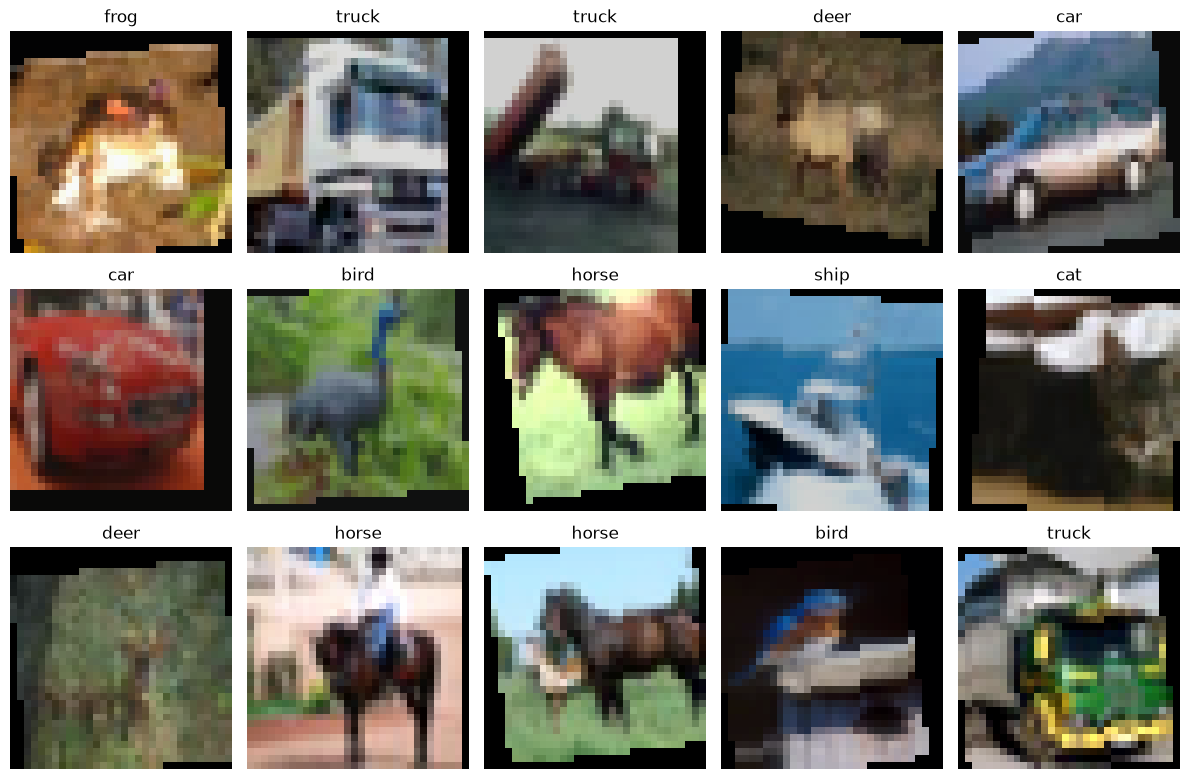

In [3]:
classes = ['airplane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    
    if torch.is_tensor(img):
        img = img.permute(1, 2, 0).numpy()
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = img * std + mean
    img = np.clip(img, 0, 1)
    
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # this changes the device being used for calculations, since i have a nvidia gpu cuda will serve as a service to make use of the gpu
print(f"Device {device}")

Device cuda


In [5]:
class CIFAR10Classifier(nn.Module):
    def __init__(self, filters=[3,64,128,256], layers=[128], image_width=32, output=10, kernel_size=3, padding=1, pooling=2, dropout_rate=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=filters[0],
            out_channels=filters[1],
            kernel_size=kernel_size,
            padding=padding
        )
        self.batchnorm1 = nn.BatchNorm2d(filters[1])
        self.pool1 = nn.MaxPool2d(pooling, pooling)
        image_width //= pooling

        self.conv2 = nn.Conv2d(
            in_channels=filters[1],
            out_channels=filters[2],
            kernel_size=kernel_size,
            padding=padding
        )
        self.batchnorm2 = nn.BatchNorm2d(filters[2])
        self.pool2 = nn.MaxPool2d(pooling, pooling)
        image_width //= pooling

        self.conv3 = nn.Conv2d(
            in_channels=filters[2],
            out_channels=filters[3],
            kernel_size=kernel_size,
            padding=padding
        )
        self.batchnorm3 = nn.BatchNorm2d(filters[3])
        self.pool3 = nn.MaxPool2d(pooling, pooling)
        image_width //= pooling

        self.fc1 = nn.Linear(filters[3] * image_width**2, layers[0])
        self.fc2 = nn.Linear(layers[0], output)

        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [6]:
model = CIFAR10Classifier().to(device)

Epoch 1, Loss 1.8676
Epoch 2, Loss 1.5947
Epoch 3, Loss 1.4683
Epoch 4, Loss 1.3840
Epoch 5, Loss 1.3165
Epoch 6, Loss 1.2785
Epoch 7, Loss 1.2333
Epoch 8, Loss 1.2078
Epoch 9, Loss 1.1780
Epoch 10, Loss 1.1592
Epoch 11, Loss 1.1388
Epoch 12, Loss 1.1274
Epoch 13, Loss 1.1096
Epoch 14, Loss 1.0980
Epoch 15, Loss 1.0878
Epoch 16, Loss 1.0745
Epoch 17, Loss 1.0655
Epoch 18, Loss 1.0533
Epoch 19, Loss 1.0501
Epoch 20, Loss 1.0390
Epoch 21, Loss 1.0333
Epoch 22, Loss 1.0253
Epoch 23, Loss 1.0210
Epoch 24, Loss 1.0200
Epoch 25, Loss 1.0101
Epoch 26, Loss 1.0023
Epoch 27, Loss 1.0028
Epoch 28, Loss 0.9923
Epoch 29, Loss 0.9893
Epoch 30, Loss 0.9859
Epoch 31, Loss 0.9821
Epoch 32, Loss 0.9730
Epoch 33, Loss 0.9690
Epoch 34, Loss 0.9710
Epoch 35, Loss 0.9639
Epoch 36, Loss 0.9554
Epoch 37, Loss 0.9528
Epoch 38, Loss 0.9526
Epoch 39, Loss 0.9438
Epoch 40, Loss 0.9443
Epoch 41, Loss 0.9434
Epoch 42, Loss 0.9357
Epoch 43, Loss 0.9344
Epoch 44, Loss 0.9295
Epoch 45, Loss 0.9308
Epoch 46, Loss 0.92

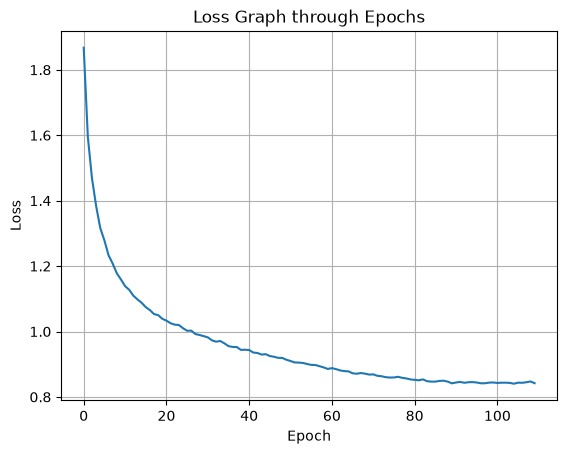

In [7]:
lf = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 110

train_losses = []

scheduler = CosineAnnealingLR(optimizer, T_max=100)

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = lf(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}, Loss {avg_loss:.4f}")

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Graph through Epochs")
plt.grid(True)
plt.show()

In [ ]:
def eval(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

model = CIFAR10Classifier()
model.load_state_dict(torch.load('cifar10.pth'))

acc = eval(model, test_loader)
print(f"Accuracy {acc*100:.2f}%")

Accuracy 85.86%


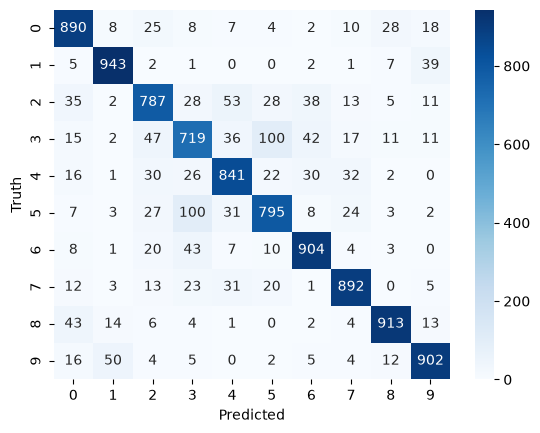

In [9]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

In [10]:
torch.save(model.state_dict(), 'cifar10.pth')